## Dates ordered

1. Order Date from Orders

2. Order Date from Order Process Data - from the warehouse, is it the same as from orders? Customers can send orders every day, but the WH only operates from Mon. to Fri.. Orders received on weekends are processed on Monday.

3. Ready to Ship Date from InternStudy Data - ready to ship at warehouse

4. On Truck Scan Date from Order Process Date - order picked up by logisticks company?

4. Pickup Date from InternStudy Data - actual pick up from warehouse, does this match day reported from logistics company?

5. Arrival Scan Date from Campaing Data - the day customer scans and claims order arrived, not regular only done through promotion

**Goal: To check whether orders are processed in the warehouse and made ready to ship, normally within 2 days.**

**To check Order processing time = On Truck Scan Date − Order Date**

**To determine whether the warehouse is generally meeting the 2-day target.**

In [1]:
import pandas as pd

In [8]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [9]:

order_process_raw = pd.read_excel("/Users/mangchinpar/Desktop/DA File/Muesli-Project-Group3-/data/Muesli Project raw data.xlsx", sheet_name='Order Process Data')
order_process_raw.head()

,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing


In [4]:
order_process_raw.head()

,Row ID,Order ID,Order Date,On Truck Scan Date,Ship Mode
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing


In [5]:
order_process_raw.shape

(5899, 5)

In [6]:
order_process_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 5899 entries, 0 to 5898
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Row ID              5899 non-null   int64         
 1   Order ID            5899 non-null   str           
 2   Order Date          5899 non-null   datetime64[us]
 3   On Truck Scan Date  5899 non-null   datetime64[us]
 4   Ship Mode           5899 non-null   str           
dtypes: datetime64[us](2), int64(1), str(2)
memory usage: 230.6 KB


In [7]:
order_process_raw.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
On Truck Scan Date    0
Ship Mode             0
dtype: int64

In [10]:
order_process_raw.duplicated().sum()

np.int64(0)

In [11]:
order_process_raw.columns = (
    order_process_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('-', '_')
)

order_process_raw.head()

,row_id,order_id,order_date,on_truck_scan_date,ship_mode
0,3074,CA-2019-125206,2019-01-03,2019-01-07,Express
1,4919,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
2,4920,CA-2019-160304,2019-01-02,2019-01-09,Standard Processing
3,8604,US-2019-116365,2019-01-03,2019-01-09,Standard Processing
4,8605,US-2019-116365,2019-01-03,2019-01-09,Standard Processing


**To change to correct datetime**

In [ ]:
order_process_raw['order_date'] = pd.to_datetime(order_process_raw['order_date'])

In [ ]:
order_process_raw['on_truck_scan_date'] = pd.to_datetime(order_process_raw['on_truck_scan_date'])

**To check the date range to make sure whether the date make sense**

In [20]:
print("Order date:")
print(order_process_raw['order_date'].min())
print(order_process_raw['order_date'].max())

print("\nTruck scan date:")
print(order_process_raw['on_truck_scan_date'].min())
print(order_process_raw['on_truck_scan_date'].max())

Order date:
2019-01-02 00:00:00
2020-12-30 00:00:00

Truck scan date:
2019-01-07 00:00:00
2021-01-06 00:00:00


**To check for invalid dates to make sure no order was scanned before it was ordered.**

In [21]:
invalid_dates = order_process_raw[
    order_process_raw['on_truck_scan_date'] < order_process_raw['order_date']
]

len(invalid_dates)

0

**To calculate warehouse processing time**

In [22]:
order_process_raw['processing_days'] = (
    order_process_raw['on_truck_scan_date'] -
    order_process_raw['order_date']
).dt.days

In [23]:
order_process_raw[['order_date', 'on_truck_scan_date', 'processing_days']].head()

,order_date,on_truck_scan_date,processing_days
0,2019-01-03,2019-01-07,4
1,2019-01-02,2019-01-09,7
2,2019-01-02,2019-01-09,7
3,2019-01-03,2019-01-09,6
4,2019-01-03,2019-01-09,6


In [24]:
order_process_raw['processing_days'].describe()

count    5899.000000
mean        6.120529
std         2.509031
min         0.000000
25%         5.000000
50%         7.000000
75%         8.000000
max        12.000000
Name: processing_days, dtype: float64

**Average processing time = 6.12 days. Median processing time = 7 days. based on the current data, the warehouse is not normally processing orders within 2 days.**

**To check 2 days target**

In [25]:
order_process_raw['within_2_days'] = (
    order_process_raw['processing_days'] <= 2
)

In [26]:
order_process_raw['within_2_days'].value_counts()

within_2_days
False    5277
True      622
Name: count, dtype: int64

In [27]:
order_process_raw['within_2_days'].mean() * 100

np.float64(10.54416002712324)

**This means 10.54% of your orders were processed within 2 days.**

**How many orders miss the target?**

In [28]:
orders_over_2_days = (
    order_process_raw['processing_days'] > 2
).sum()

orders_over_2_days

np.int64(5277)

In [29]:
orders_over_2_days / len(order_process_raw) * 100

np.float64(89.45583997287676)

**To analyze processing time by Ship Mode, because different shipping methods may have different warehouse processing patterns.**

In [30]:
order_process_raw.groupby('ship_mode')['processing_days'].describe()

,count,mean,std,min,25%,50%,75%,max
ship_mode,,,,,,,,
Express,1303.0,2.568688,1.638534,0.0,1.0,3.0,4.0,6.0
Standard Processing,4596.0,7.127502,1.651674,2.0,6.0,7.0,8.0,12.0


In [31]:
order_process_raw.groupby('ship_mode')['within_2_days'].mean() * 100

ship_mode
Express                47.659248
Standard Processing     0.021758
Name: within_2_days, dtype: float64

**Express: about 47.66% of orders met the 2-day target. Standard Processing: only about 0.02% met the 2-day target.**

**To identify extreme delays**

In [32]:
Q1 = order_process_raw['processing_days'].quantile(0.25)
Q3 = order_process_raw['processing_days'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 5.0
Q3: 8.0
IQR: 3.0
Lower bound: 0.5
Upper bound: 12.5


In [34]:
outliers = order_process_raw[
    (order_process_raw['processing_days'] < lower_bound) |
    (order_process_raw['processing_days'] > upper_bound)
]

In [35]:
outliers

,row_id,order_id,order_date,on_truck_scan_date,ship_mode,scan_delay,processing_days,within_2_days
179,1705,CA-2019-106306,2019-03-08,2019-03-08,Express,0,0,True
181,9698,CA-2019-122511,2019-03-11,2019-03-11,Express,0,0,True
282,7695,CA-2019-118899,2019-03-22,2019-03-22,Express,0,0,True
291,3371,CA-2019-134887,2019-03-25,2019-03-25,Express,0,0,True
317,8572,CA-2019-162222,2019-04-03,2019-04-03,Express,0,0,True
...,...,...,...,...,...,...,...,...
5594,6716,CA-2020-107629,2020-12-14,2020-12-14,Express,0,0,True
5687,4104,CA-2020-137456,2020-12-21,2020-12-21,Express,0,0,True
5698,883,US-2020-123463,2020-12-23,2020-12-23,Express,0,0,True
5746,4620,CA-2020-145219,2020-12-24,2020-12-24,Express,0,0,True


In [36]:
len(outliers)

152

In [37]:
# to inspect the outlier

outliers[
    ['order_id',
     'order_date',
     'on_truck_scan_date',
     'ship_mode',
     'processing_days']
].sort_values('processing_days', ascending=False)

,order_id,order_date,on_truck_scan_date,ship_mode,processing_days
179,CA-2019-106306,2019-03-08,2019-03-08,Express,0
4021,US-2020-118941,2020-08-12,2020-08-12,Express,0
3748,CA-2020-168109,2020-07-03,2020-07-03,Express,0
3749,CA-2020-168109,2020-07-03,2020-07-03,Express,0
3768,US-2020-152492,2020-07-06,2020-07-06,Express,0
...,...,...,...,...,...
2275,US-2019-148803,2019-12-11,2019-12-11,Express,0
2276,CA-2019-162187,2019-12-11,2019-12-11,Express,0
2277,CA-2019-162187,2019-12-11,2019-12-11,Express,0
2278,CA-2019-162187,2019-12-11,2019-12-11,Express,0


**To analyze the distribution**


In [38]:
order_process_raw['processing_days'].value_counts().sort_index()

processing_days
0      152
1      248
2      222
3      373
4      435
5      602
6      765
7     1165
8     1022
9      565
10     318
11      26
12       6
Name: count, dtype: int64

In [ ]:
#To show inn percentage
order_process_raw['processing_days'].value_counts(
    normalize=True
).sort_index() * 100

processing_days
0      2.576708
1      4.204102
2      3.763350
3      6.323106
4      7.374131
5     10.205120
6     12.968300
7     19.749110
8     17.324970
9      9.577895
10     5.390744
11     0.440753
12     0.101712
Name: proportion, dtype: float64

**To create visualization**

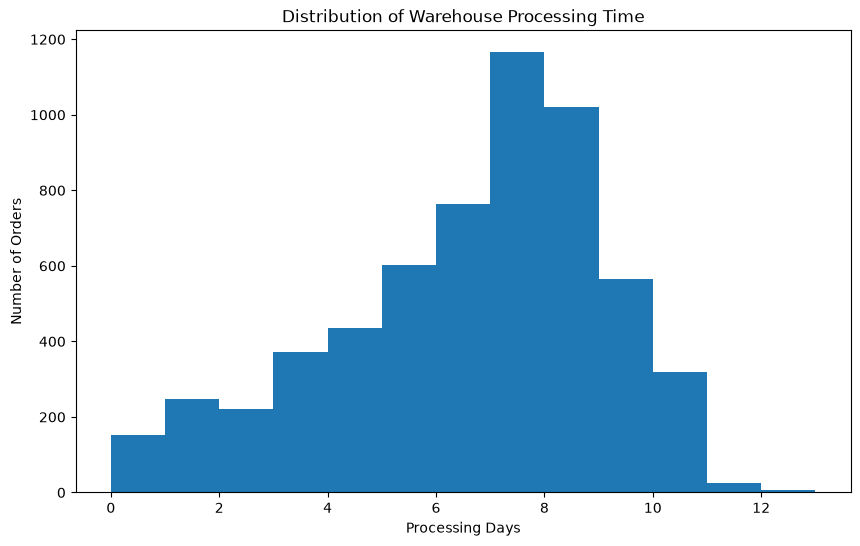

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(order_process_raw['processing_days'], bins=range(
    order_process_raw['processing_days'].min(),
    order_process_raw['processing_days'].max() + 2
))
plt.xlabel('Processing Days')
plt.ylabel('Number of Orders')
plt.title('Distribution of Warehouse Processing Time')
plt.show()